## What is a Correlation Matrix Heatmap?

A correlation matrix heatmap visualizes pairwise correlations between numerical variables.

Correlation types:

Pearson → linear relationship (default)

Spearman → monotonic (rank-based)

Kendall → ordinal / robust

### Basic Correlation Matrix Heatmap (Seaborn)

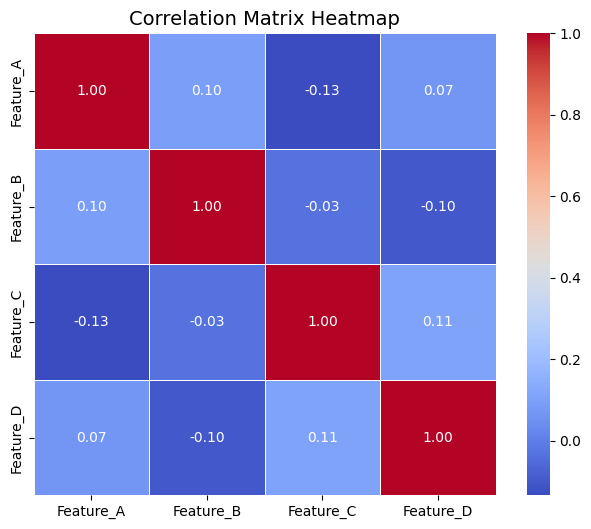

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample dataset
np.random.seed(42)

df = pd.DataFrame({
    "Feature_A": np.random.normal(0, 1, 200),
    "Feature_B": np.random.normal(1, 1.5, 200),
    "Feature_C": np.random.normal(2, 0.8, 200),
    "Feature_D": np.random.normal(0, 2, 200),
})

# Compute correlation matrix
corr = df.corr()

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.show()


### Correlation Heatmap with Mask (Upper Triangle Hidden)

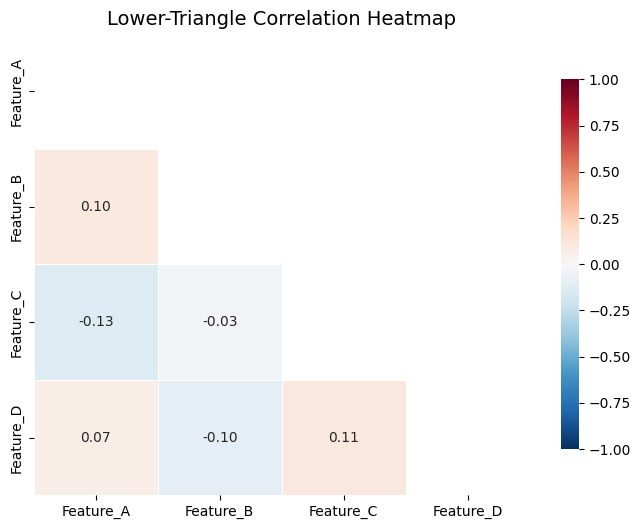

In [2]:
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    linewidths=0.6,
    cbar_kws={"shrink": 0.8}
)

plt.title("Lower-Triangle Correlation Heatmap", fontsize=14)
plt.show()


### Correlation Heatmap with Different Correlation Methods

In [3]:
corr_pearson = df.corr(method="pearson")


In [4]:
corr_spearman = df.corr(method="spearman")

In [5]:
corr_kendall = df.corr(method="kendall")


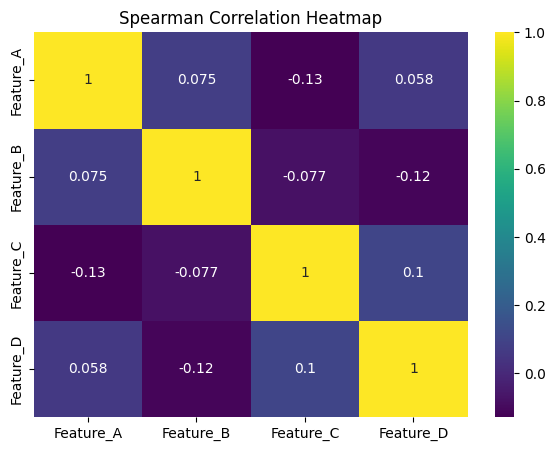

In [6]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_spearman, annot=True, cmap="viridis")
plt.title("Spearman Correlation Heatmap")
plt.show()


### Advanced Styling (Professional / Presentation-Level)

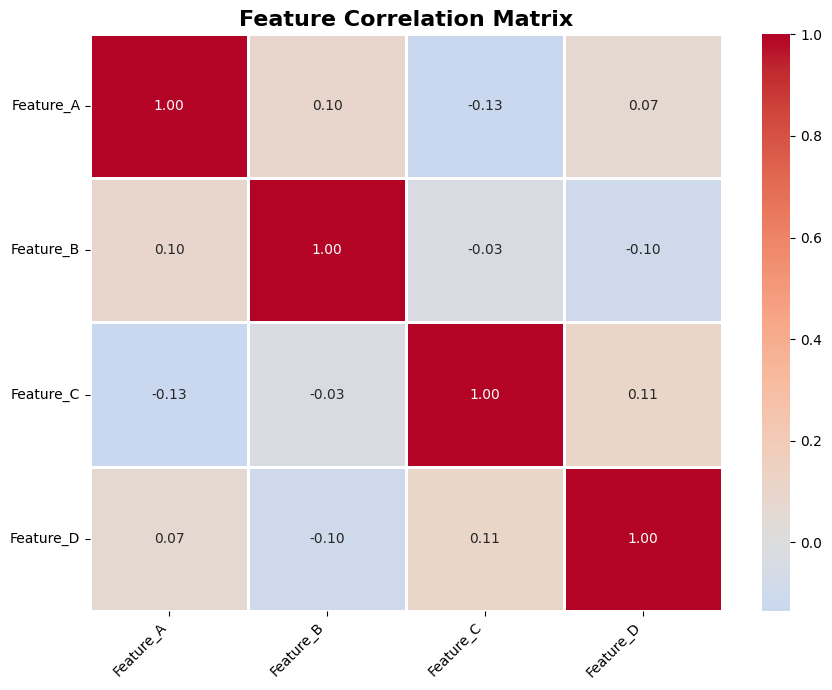

In [7]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=1,
    linecolor="white",
    cbar=True,
    annot_kws={"size": 10}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Feature Correlation Matrix", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()


### Correlation Heatmap with Large Dataset (Auto-filter numeric columns)

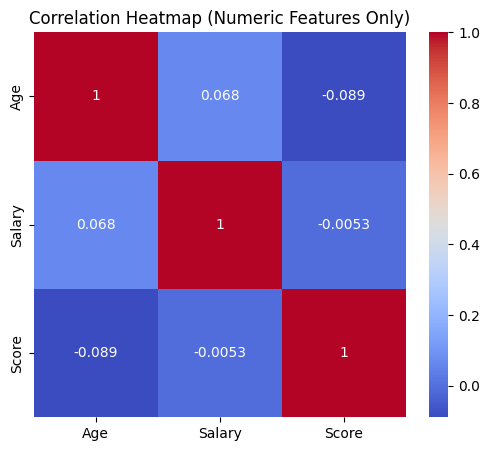

In [8]:
# Example mixed dataset
df_mixed = pd.DataFrame({
    "Age": np.random.randint(18, 60, 150),
    "Salary": np.random.randint(30000, 90000, 150),
    "Score": np.random.normal(70, 10, 150),
    "Department": np.random.choice(["HR", "Tech", "Sales"], 150)
})

# Select only numeric columns
numeric_df = df_mixed.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()


### Correlation Heatmap with Threshold Highlighting

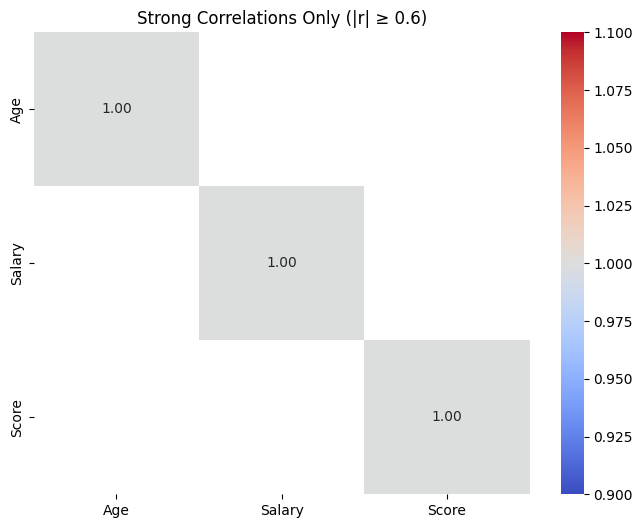

In [9]:
threshold = 0.6

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    mask=np.abs(corr) < threshold,
    cbar=True
)

plt.title("Strong Correlations Only (|r| ≥ 0.6)")
plt.show()


### Clustered Correlation Heatmap (VERY IMPORTANT)

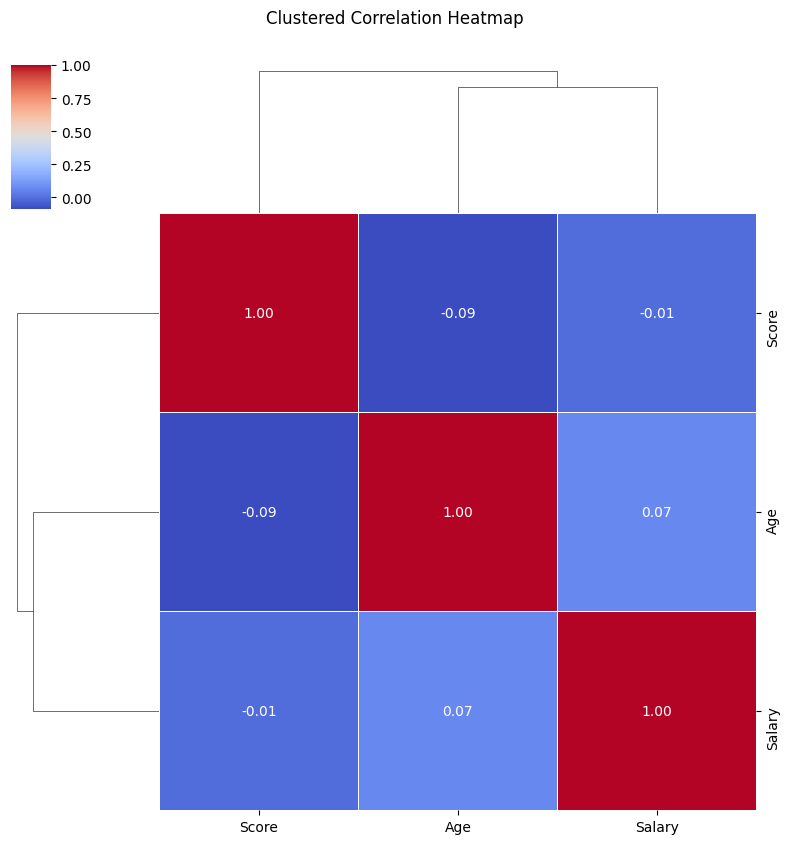

In [10]:
sns.clustermap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    figsize=(8, 8),
    linewidths=0.5
)
plt.suptitle("Clustered Correlation Heatmap", y=1.05)
plt.show()


### Interactive Correlation Heatmap (Plotly)

In [11]:
def plot_correlation_heatmap(
    df,
    method="pearson",
    figsize=(8, 6),
    cmap="coolwarm",
    annot=True
):
    corr = df.select_dtypes(include=np.number).corr(method=method)

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        annot=annot,
        fmt=".2f",
        cmap=cmap,
        center=0,
        linewidths=0.5
    )
    plt.title(f"{method.capitalize()} Correlation Matrix")
    plt.show()


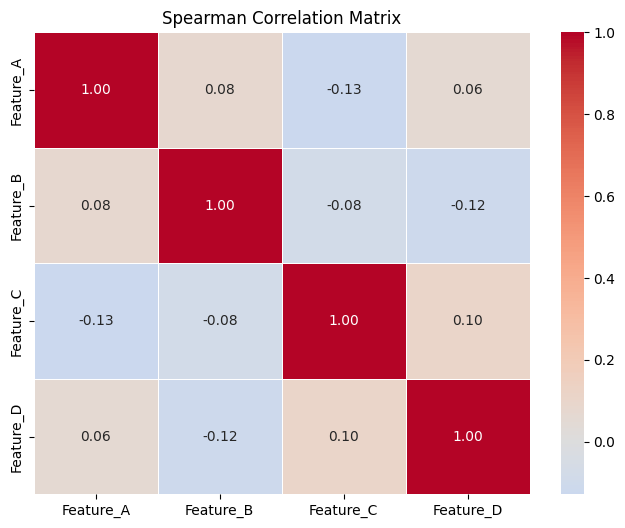

In [12]:
plot_correlation_heatmap(df, method="spearman")
